# PENGELOMPOKAN PROVINSI DI INDONESIA BERDASARKAN ANGKA PARTISIPASI MURNI PENDIDIKAN MENGGUNAKAN ALGORITMA K-MEANS

## 1. Business Understanding




**Permasalahan**: Indonesia sebagai negara kepulauan yang luas memiliki kesenjangan yang cukup signifikan dalam akses dan partisipasi pendidikan di berbagai provinsi. Memahami perbedaan tersebut sangat penting untuk mendukung penyusunan kebijakan yang tepat sasaran serta alokasi sumber daya yang lebih efektif.

**Tujuan**: Melakukan klasterisasi provinsi-provinsi di Indonesia berdasarkan Angka Partisipasi Murni (APM) pada berbagai jenjang pendidikan. Hasil klasterisasi ini diharapkan dapat mengidentifikasi kelompok provinsi yang memiliki pola partisipasi pendidikan yang serupa, sehingga dapat menjadi dasar dalam perumusan kebijakan pendidikan yang lebih terarah, efektif, dan sesuai dengan karakteristik masing-masing daerah guna meningkatkan pemerataan akses serta kualitas pendidikan.

## 2. Data Understanding


In [1]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━ 4.1/9.2 MB 54.7 MB/s eta 0:00:01Requirement already satisfied: smmap<6,>=3.0.1 in /usr/local/lib/python3.12/dist-packages (from gitdb<5,>=4.0.1->gitpython!=3.1.19,<4,>=3.0.7->streamlit) (5.0.3)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 41.9 MB/s eta 0:00:00


In [3]:
import pandas as pd

# Load the Excel file
df = pd.read_excel("Angka Partisipasi Murni (APM) Menurut Provinsi dan Jenjang Pendidikan, 2025.xlsx")

In [11]:
import io

buffer = io.StringIO()
df.info(buf=buffer)
print(buffer.getvalue())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Provinsi  38 non-null     object 
 1   APM_SD    38 non-null     float64
 2   APM_SMP   38 non-null     float64
 3   APM_SMA   38 non-null     float64
dtypes: float64(3), object(1)
memory usage: 1.3+ KB



In [12]:
# Display the first 5 rows of the DataFrame
display(df.head())

,Provinsi,APM_SD,APM_SMP,APM_SMA
0,ACEH,96.32,81.37,70.36
1,SUMATERA UTARA,95.99,77.41,70.40
2,SUMATERA BARAT,97.06,82.70,71.57
3,RIAU,97.54,81.40,65.22
4,JAMBI,97.02,78.47,63.05


In [6]:
# Infromasi Dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   38 Provinsi    38 non-null     object 
 1   SD/sederajat   38 non-null     float64
 2   SMP/sederajat  38 non-null     float64
 3   SMA/sederajat  38 non-null     float64
dtypes: float64(3), object(1)
memory usage: 1.3+ KB


In [13]:
# Deskriptif Statistic
display(df.describe())

,APM_SD,APM_SMP,APM_SMA
count,38.000000,38.000000,38.000000
mean,95.092105,77.339737,64.423947
std,5.490588,7.456689,9.014287
min,72.550000,54.330000,35.590000
25%,95.675000,75.070000,61.525000
50%,96.390000,78.470000,65.610000
75%,97.547500,81.467500,70.245000
max,98.770000,88.670000,78.420000


### **Ringkasan Data Understanding**

* Dataset yang digunakan terdiri dari 38 baris data, di mana setiap baris merepresentasikan satu provinsi di Indonesia.
* Dataset memiliki 4 atribut, yaitu Provinsi, APM SD/sederajat, APM SMP/sederajat, dan APM SMA/sederajat.
* Seluruh atribut numerik, yaitu SD/sederajat, SMP/sederajat, dan SMA/sederajat, bertipe float64 serta tidak memiliki nilai yang hilang (missing values) berdasarkan hasil pemeriksaan menggunakan df.info(). Kondisi ini menunjukkan bahwa data telah siap digunakan untuk proses analisis tanpa memerlukan penanganan data yang hilang.
* Berdasarkan statistik deskriptif, rata-rata Angka Partisipasi Murni (APM) pada jenjang SD/sederajat merupakan yang tertinggi dibandingkan jenjang pendidikan lainnya. Nilai rata-rata tersebut kemudian menurun pada jenjang SMP/sederajat dan semakin rendah pada jenjang SMA/sederajat. Pola ini mengindikasikan bahwa tingkat partisipasi pendidikan cenderung berkurang seiring meningkatnya jenjang pendidikan.
* Selain itu, terdapat variasi yang cukup besar pada nilai APM antarprovinsi, terutama pada jenjang SMA/sederajat, yang ditunjukkan oleh rentang nilai (range) yang relatif lebar. Variabilitas ini menunjukkan adanya perbedaan tingkat partisipasi pendidikan antarwilayah di Indonesia. Oleh karena itu, penerapan metode K-Means Clustering menjadi relevan untuk mengelompokkan provinsi-provinsi yang memiliki karakteristik partisipasi pendidikan yang serupa, sehingga dapat membantu dalam identifikasi pola serta mendukung penyusunan kebijakan pendidikan yang lebih tepat sasaran.

## 3. Data Preparation

Tahap ini melibatkan proses pembersihan dan transformasi data agar siap digunakan dalam algoritma **K-Means Clustering**. Proses diawali dengan **mengubah nama kolom (renaming columns)** menjadi lebih sederhana dan mudah dipahami. Langkah ini bertujuan untuk meningkatkan keterbacaan data serta mempermudah proses analisis dan pengolahan data pada tahapan selanjutnya. Dengan penamaan kolom yang lebih jelas, proses interpretasi hasil analisis juga menjadi lebih mudah dilakukan.


In [14]:
# Mengubah nama kolom untuk meningkatkan kejelasan dan keterbacaan data
df.rename(columns={
    '38 Provinsi': 'Provinsi',
    'SD/sederajat': 'APM_SD',
    'SMP/sederajat': 'APM_SMP',
    'SMA/sederajat': 'APM_SMA'
}, inplace=True)

# Menampilkan beberapa baris pertama dataset setelah perubahan nama kolom
display(df.head())

,Provinsi,APM_SD,APM_SMP,APM_SMA
0,ACEH,96.32,81.37,70.36
1,SUMATERA UTARA,95.99,77.41,70.40
2,SUMATERA BARAT,97.06,82.70,71.57
3,RIAU,97.54,81.40,65.22
4,JAMBI,97.02,78.47,63.05


### Cek duplikat dan missing Value

In [15]:
# Cek duplikat
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

# Cek data kosong
missing_values = df.isnull().sum()
print("\nMissing values per column:")
print(missing_values)

Number of duplicate rows: 0

Missing values per column:
Provinsi    0
APM_SD      0
APM_SMP     0
APM_SMA     0
dtype: int64


### Feature Selection and Scaling

Pada proses K-Means Clustering, diperlukan pemilihan fitur numerik yang akan digunakan sebagai dasar pembentukan klaster. Dalam penelitian ini, fitur yang dipilih adalah nilai Angka Partisipasi Murni (APM) pada berbagai jenjang pendidikan, yaitu SD/sederajat, SMP/sederajat, dan SMA/sederajat, karena fitur-fitur tersebut merepresentasikan karakteristik partisipasi pendidikan di setiap provinsi.

Selain pemilihan fitur, proses penskalaan data (scaling) juga sangat penting dilakukan. Hal ini karena algoritma K-Means bekerja berdasarkan perhitungan jarak antar data. Jika terdapat perbedaan skala yang cukup besar antar fitur, maka fitur dengan nilai yang lebih besar dapat memberikan pengaruh yang lebih dominan dalam proses pengelompokan sehingga hasil klaster menjadi kurang optimal.

Untuk mengatasi hal tersebut, digunakan metode StandardScaler yang melakukan standardisasi data dengan mengubah setiap fitur agar memiliki rata-rata (mean) sebesar 0 dan varians (variance) sebesar 1. Dengan demikian, seluruh fitur memiliki skala yang sebanding dan dapat berkontribusi secara proporsional dalam proses pembentukan klaster oleh algoritma K-Means.

In [16]:
from sklearn.preprocessing import StandardScaler

# Select the features for clustering
X = df[['APM_SD', 'APM_SMP', 'APM_SMA']]

# Initialize the StandardScaler
scaler = StandardScaler()

# Scale the features
X_scaled = scaler.fit_transform(X)

# Convert the scaled features back to a DataFrame for better readability
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Display the first few rows of the scaled data
display(X_scaled_df.head())

,APM_SD,APM_SMP,APM_SMA
0,0.226638,0.547745,0.667356
1,0.165729,0.009549,0.671853
2,0.363224,0.728502,0.803389
3,0.451819,0.551822,0.089496
4,0.355841,0.153612,-0.154465


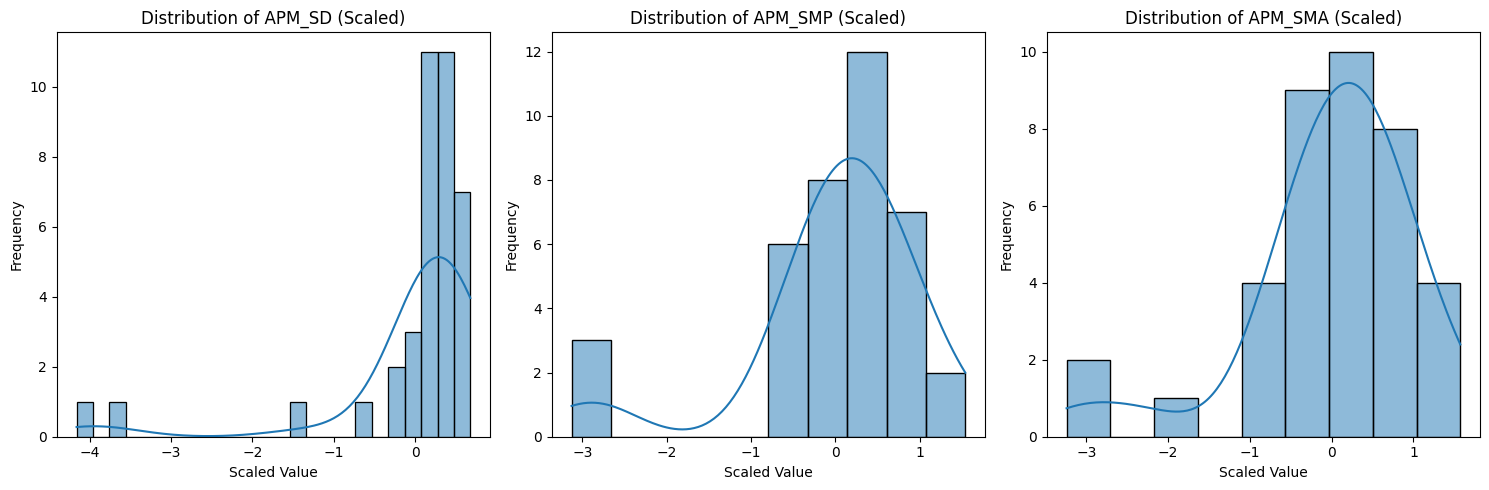

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the distribution of scaled features
plt.figure(figsize=(15, 5))
for i, column in enumerate(X_scaled_df.columns):
    plt.subplot(1, 3, i + 1)
    sns.histplot(X_scaled_df[column], kde=True)
    plt.title(f'Distribution of {column} (Scaled)')
    plt.xlabel('Scaled Value')
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## 4. Modeling

Pada tahap ini, akan menerapkan algoritma **K-Means Clustering** untuk mengelompokkan provinsi berdasarkan tingkat partisipasi pendidikan mereka. Langkah pertama yang dilakukan adalah menentukan jumlah klaster (**k**) yang optimal.


### Elbow Method to Determine Optimal k

Metode Elbow (Elbow Method) merupakan metode heuristik yang digunakan untuk menentukan jumlah klaster yang optimal dalam suatu dataset. Prinsipnya adalah menjalankan algoritma K-Means Clustering untuk berbagai nilai k (misalnya dari 1 hingga 10), kemudian menghitung jumlah kuadrat jarak (inertia) dari setiap data ke pusat klaster yang ditetapkan.

Selanjutnya, nilai inertia diplot terhadap jumlah klaster. Grafik yang dihasilkan biasanya menyerupai bentuk lengan, dan titik "siku" (elbow) atau titik belokan pada kurva menunjukkan jumlah klaster yang paling optimal. Pada titik tersebut, penambahan jumlah klaster tidak lagi memberikan penurunan inertia yang signifikan, sehingga dianggap sebagai jumlah klaster terbaik untuk digunakan.

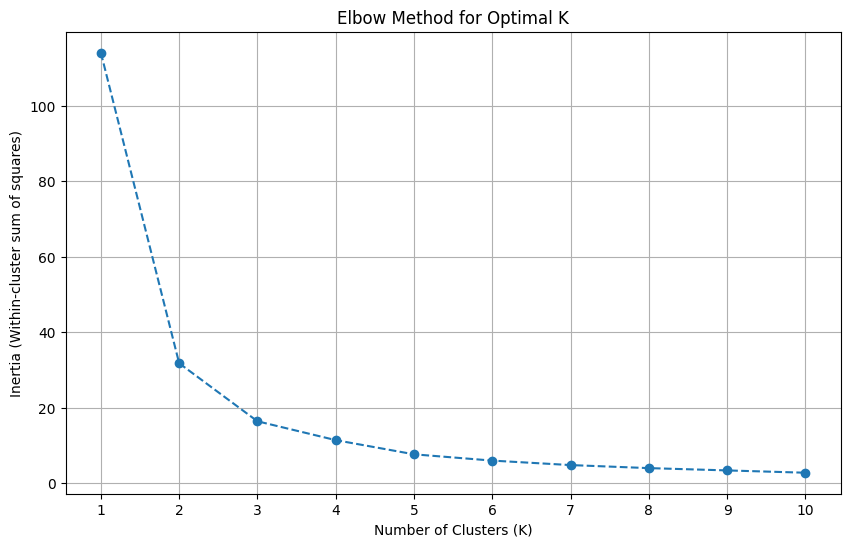

In [18]:
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore') # Suppress KMeans convergence warnings

# Calculate inertia for different numbers of clusters
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # Added n_init to suppress warning
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-cluster sum of squares)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

### Applying K-Means Clustering

Berdasarkan hasil Metode Elbow, dipilih nilai k = 3 sebagai jumlah klaster yang optimal. Selanjutnya, algoritma K-Means Clustering diterapkan menggunakan nilai k tersebut untuk mengelompokkan data ke dalam tiga klaster.

Setelah proses klasterisasi selesai, label klaster yang dihasilkan akan ditambahkan kembali ke DataFrame asli sehingga setiap provinsi memiliki informasi mengenai klaster tempatnya berada. Dengan demikian, hasil pengelompokan dapat dianalisis dan diinterpretasikan lebih lanjut berdasarkan karakteristik masing-masing klaster.

In [19]:
# Initialize KMeans with the optimal number of clusters (k=3)
k_optimal = 3
kmeans_model = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)

# Fit KMeans to the scaled data and predict clusters
df['Cluster'] = kmeans_model.fit_predict(X_scaled)

# Display the first few rows with the assigned clusters
display(df.head())

,Provinsi,APM_SD,APM_SMP,APM_SMA,Cluster
0,ACEH,96.32,81.37,70.36,0
1,SUMATERA UTARA,95.99,77.41,70.40,0
2,SUMATERA BARAT,97.06,82.70,71.57,0
3,RIAU,97.54,81.40,65.22,0
4,JAMBI,97.02,78.47,63.05,2


### Cluster Analysis

Setelah setiap provinsi berhasil dikelompokkan ke dalam klaster, langkah selanjutnya adalah menganalisis karakteristik masing-masing klaster untuk memahami faktor-faktor yang membedakannya.

Analisis dilakukan dengan menghitung nilai rata-rata (mean) dari variabel APM_SD, APM_SMP, dan APM_SMA pada setiap klaster. Nilai rata-rata ini memberikan gambaran mengenai tingkat partisipasi pendidikan yang menjadi ciri khas dari masing-masing kelompok provinsi.

Selain itu, dilakukan juga perhitungan jumlah provinsi yang termasuk dalam setiap klaster. Informasi ini berguna untuk mengetahui distribusi anggota pada tiap klaster serta melihat apakah terdapat klaster yang berisi banyak atau sedikit provinsi.

Melalui analisis tersebut, dapat dilakukan interpretasi terhadap hasil klasterisasi, seperti mengidentifikasi klaster dengan tingkat partisipasi pendidikan tinggi, sedang, atau rendah berdasarkan nilai rata-rata APM pada setiap jenjang pendidikan.

In [20]:
# Calculate the mean of APM values for each cluster
cluster_means = df.groupby('Cluster')[['APM_SD', 'APM_SMP', 'APM_SMA']].mean()
display(cluster_means)

# Count the number of provinces in each cluster
cluster_counts = df['Cluster'].value_counts().sort_index()
print("\nNumber of provinces per cluster:")
display(cluster_counts)

,APM_SD,APM_SMP,APM_SMA
Cluster,,,
0,97.220000,81.970000,70.545789
1,78.346667,56.070000,40.313333
2,95.705000,75.829375,61.675000



Number of provinces per cluster:


,count
Cluster,
0,19
1,3
2,16


#### Interpretasi Klaster:

Based on the `cluster_means`:

Berdasarkan hasil cluster_means, karakteristik masing-masing klaster dapat dijelaskan sebagai berikut:

**Klaster 0 (19 Provinsi)**: Provinsi-provinsi dalam klaster ini menunjukkan nilai APM yang tinggi pada seluruh jenjang pendidikan (SD, SMP, dan SMA). Klaster ini kemungkinan terdiri dari daerah dengan infrastruktur pendidikan yang lebih baik serta tingkat partisipasi siswa yang tinggi.
**Klaster 1 (3 Provinsi)**: Klaster ini memiliki nilai APM yang relatif rendah pada semua jenjang pendidikan. Provinsi-provinsi dalam kelompok ini kemungkinan menghadapi berbagai tantangan terkait akses pendidikan, pemerataan fasilitas, maupun keberlanjutan pendidikan peserta didik.
**Klaster 2 (16 Provinsi)**: Provinsi-provinsi dalam klaster ini memiliki nilai APM pada tingkat menengah (sedang). Tingkat partisipasi pendidikannya berada di bawah Klaster 0, tetapi masih jauh lebih tinggi dibandingkan Klaster 1. Hal ini menunjukkan bahwa daerah-daerah dalam klaster ini memiliki tingkat partisipasi pendidikan yang cukup baik, meskipun masih terdapat ruang untuk peningkatan.

### Cluster Visualization

Untuk memperoleh pemahaman yang lebih baik mengenai perbedaan dan karakteristik masing-masing klaster, hasil klasterisasi perlu divisualisasikan. Karena analisis menggunakan tiga variabel, yaitu APM_SD, APM_SMP, dan APM_SMA, maka grafik sebar tiga dimensi (3D Scatter Plot) merupakan pilihan yang tepat.

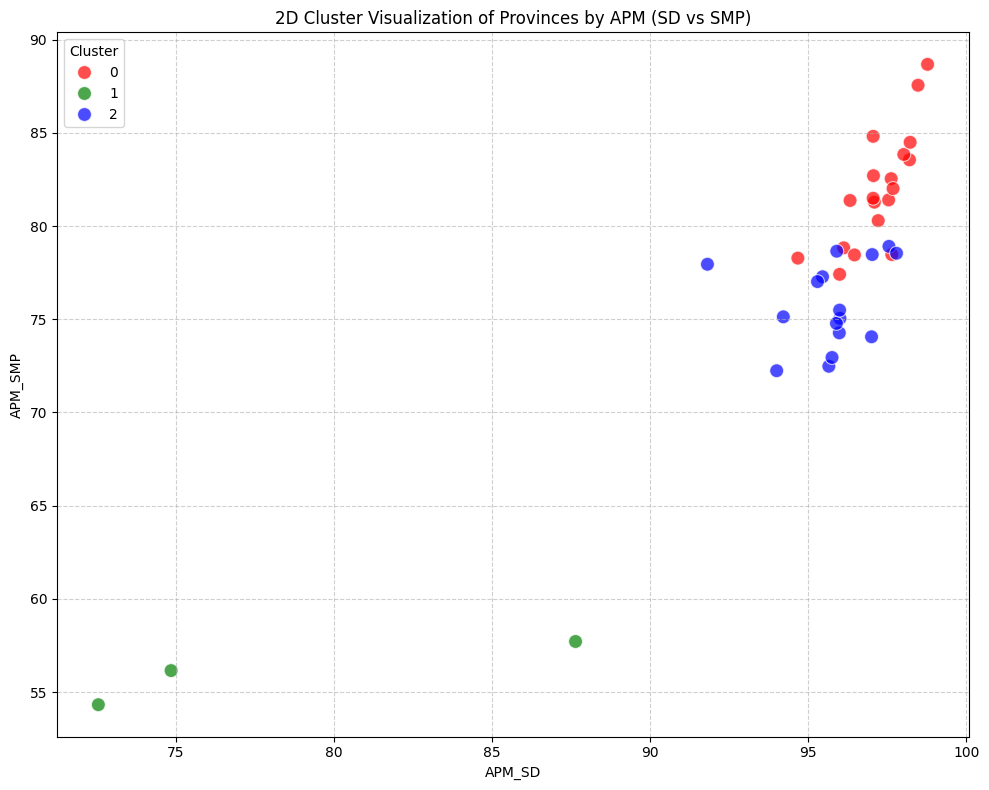

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a 2D scatter plot of the clusters
plt.figure(figsize=(10, 8))

# Define a palette for the clusters
# Using the existing 'colors' list for consistency, or a seaborn palette
colors_palette = ['red', 'green', 'blue'] # Assuming 3 clusters

sns.scatterplot(
    data=df,
    x='APM_SD',
    y='APM_SMP',
    hue='Cluster',
    palette=colors_palette,
    s=100, # Marker size
    alpha=0.7,
    edgecolor='w' # White edge for better distinction
)

plt.title('2D Cluster Visualization of Provinces by APM (SD vs SMP)')
plt.xlabel('APM_SD')
plt.ylabel('APM_SMP')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

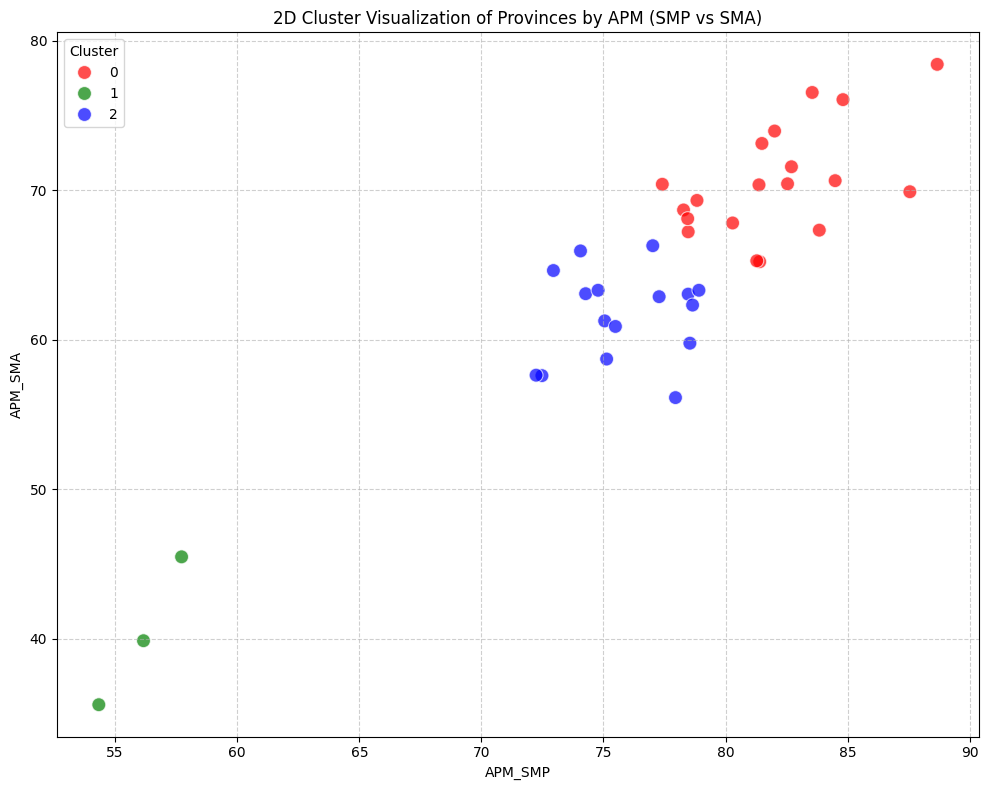

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a 2D scatter plot of the clusters using APM_SMP vs APM_SMA
plt.figure(figsize=(10, 8))

# Use the same palette for consistency
colors_palette = ['red', 'green', 'blue'] # Assuming 3 clusters

sns.scatterplot(
    data=df,
    x='APM_SMP',
    y='APM_SMA',
    hue='Cluster',
    palette=colors_palette,
    s=100, # Marker size
    alpha=0.7,
    edgecolor='w' # White edge for better distinction
)

plt.title('2D Cluster Visualization of Provinces by APM (SMP vs SMA)')
plt.xlabel('APM_SMP')
plt.ylabel('APM_SMA')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

In [23]:
for cluster_num in sorted(df['Cluster'].unique()):
    provinces_in_cluster = df[df['Cluster'] == cluster_num]['Provinsi'].tolist()
    print(f"\nCluster {cluster_num}:")
    for province in provinces_in_cluster:
        print(f"- {province}")


Cluster 0:
- ACEH
- SUMATERA UTARA
- SUMATERA BARAT
- RIAU
- BENGKULU
- LAMPUNG
- KEP. RIAU
- DKI JAKARTA
- JAWA BARAT
- JAWA TENGAH
- DI YOGYAKARTA
- JAWA TIMUR
- BANTEN
- BALI
- NUSA TENGGARA BARAT
- KALIMANTAN TIMUR
- KALIMANTAN UTARA
- SULAWESI TENGAH
- SULAWESI SELATAN

Cluster 1:
- PAPUA SELATAN
- PAPUA TENGAH
- PAPUA PEGUNUNGAN

Cluster 2:
- JAMBI
- SUMATERA SELATAN
- KEP. BANGKA BELITUNG
- NUSA TENGGARA TIMUR
- KALIMANTAN BARAT
- KALIMANTAN TENGAH
- KALIMANTAN SELATAN
- SULAWESI UTARA
- SULAWESI TENGGARA
- GORONTALO
- SULAWESI BARAT
- MALUKU
- MALUKU UTARA
- PAPUA BARAT
- PAPUA BARAT DAYA
- PAPUA


In [27]:
import warnings
warnings.filterwarnings('ignore')


!pip install geopandas plotly

import geopandas
import plotly.express as px


geojso_path = '/content/indonesia-38-provinces.geojson'  # <--- UPDATED PATH to absolute path

try:
    gdf = geopandas.read_file(geojso_path)
    print("\n--- GeoDataFrame Head (first 5 rows) ---")
    display(gdf.head())
    print("\n--- GeoDataFrame Columns ---")
    print(gdf.columns.tolist())

    def clean_province_name(name):
        name = str(name).upper().strip()
        name = name.replace('DAERAH KHUSUS IBUKOTA', 'DKI')
        name = name.replace('DAERAH ISTIMEWA', 'DI')
        name = name.replace('KEPULAUAN', 'KEP.')
        name = name.replace('PROVINSI ', '')
        name = name.replace('NUSA TENGGARA BARAT', 'NUSA TENGGARA BARAT')
        name = name.replace('NUSA TENGGARA TIMUR', 'NUSA TENGGARA TIMUR')
        return name.strip()

    df['Provinsi_clean'] = df['Provinsi'].apply(clean_province_name)

    if 'PROVINSI' in gdf.columns:
        print("Using 'PROVINSI' column from GeoJSON for matching.")
        gdf['Provinsi_clean'] = gdf['PROVINSI'].apply(clean_province_name)
    elif 'NAME_1' in gdf.columns:
        print("Using 'NAME_1' column from GeoJSON for matching.")
        gdf['Provinsi_clean'] = gdf['NAME_1'].apply(clean_province_name)
    elif 'name' in gdf.columns:
        print("Using 'name' column from GeoJSON for matching.")
        gdf['Provinsi_clean'] = gdf['name'].apply(clean_province_name)
    else:
        print("Warning: Could not find common province name column (e.g., 'PROVINSI', 'NAME_1', or 'name').")
        string_cols = [col for col in gdf.columns if gdf[col].dtype == 'object' and col != 'geometry']
        if string_cols:
            fallback_col = string_cols[0]
            print(f"Attempting to use '{fallback_col}' as the province name column in GeoJSON.")
            gdf['Provinsi_clean'] = gdf[fallback_col].apply(clean_province_name)
        else:
            raise ValueError("No suitable province name column found in GeoJSON for matching.")

    print("\n--- Cleaned Province Names (DataFrame) ---")
    print(sorted(df['Provinsi_clean'].unique()))
    print("\n--- Cleaned Province Names (GeoDataFrame) ---")
    print(sorted(gdf['Provinsi_clean'].unique()))

    gdf_merged = gdf.merge(df, left_on='Provinsi_clean', right_on='Provinsi_clean', how='left')

    if gdf_merged['Cluster'].isnull().any():
        unmatched_geojson = gdf_merged[gdf_merged['Cluster'].isnull()]['Provinsi_clean'].tolist()
        print(f"\nWarning: Some provinces in the GeoJSON could not be matched to the cluster data: {unmatched_geojson}")
        print("Please check province names for consistency between your GeoJSON and the DataFrame, paying attention to the printed lists above.")
    else:
        print("\nAll provinces matched successfully.")

    fig = px.choropleth_mapbox(
        gdf_merged,
        geojson=gdf_merged.geometry,
        locations=gdf_merged.index,
        color="Cluster",
        category_orders={"Cluster": sorted(df['Cluster'].unique())},
        color_continuous_scale="Portland",
        mapbox_style="carto-positron",
        zoom=3,
        center={"lat": -2.5, "lon": 118},
        opacity=0.7,
        hover_name="Provinsi",
        title="Peta Klasterisasi Provinsi Berdasarkan APM Pendidikan",
        labels={'Cluster': 'Klaster'}
    )

    fig.update_layout(margin={"r":0,"t":50,"l":0,"b":0})
    fig.show()

except FileNotFoundError:
    print(f"Error: GeoJSON file not found at '{geojso_path}'. Please upload the file and update the path in the code.")
except Exception as e:
    print(f"An error occurred during map generation: {e}")
    print("Please ensure your GeoJSON file is valid and its province names can be matched with the 'Provinsi' column in your data. Check the printed output for clues.")


--- GeoDataFrame Head (first 5 rows) ---


,id,KODE_PROV,PROVINSI,geometry
0,72,72,Sulawesi Tengah,"MULTIPOLYGON (((119.56117 -0.84951, 119.59325 ..."
1,76,76,Sulawesi Barat,"POLYGON ((119.56117 -0.84951, 119.30326 -1.273..."
2,73,73,Sulawesi Selatan,"MULTIPOLYGON (((120.92375 -7.28328, 120.79523 ..."
3,91-D,91,Papua Tengah,"POLYGON ((134.88549 -4.25246, 135.20778 -4.465..."
4,92-A,92,Papua Barat,"MULTIPOLYGON (((133.33844 -4.09994, 133.45902 ..."



--- GeoDataFrame Columns ---
['id', 'KODE_PROV', 'PROVINSI', 'geometry']
Using 'PROVINSI' column from GeoJSON for matching.

--- Cleaned Province Names (DataFrame) ---
['ACEH', 'BALI', 'BANTEN', 'BENGKULU', 'DI YOGYAKARTA', 'DKI JAKARTA', 'GORONTALO', 'JAMBI', 'JAWA BARAT', 'JAWA TENGAH', 'JAWA TIMUR', 'KALIMANTAN BARAT', 'KALIMANTAN SELATAN', 'KALIMANTAN TENGAH', 'KALIMANTAN TIMUR', 'KALIMANTAN UTARA', 'KEP. BANGKA BELITUNG', 'KEP. RIAU', 'LAMPUNG', 'MALUKU', 'MALUKU UTARA', 'NUSA TENGGARA BARAT', 'NUSA TENGGARA TIMUR', 'PAPUA', 'PAPUA BARAT', 'PAPUA BARAT DAYA', 'PAPUA PEGUNUNGAN', 'PAPUA SELATAN', 'PAPUA TENGAH', 'RIAU', 'SULAWESI BARAT', 'SULAWESI SELATAN', 'SULAWESI TENGAH', 'SULAWESI TENGGARA', 'SULAWESI UTARA', 'SUMATERA BARAT', 'SUMATERA SELATAN', 'SUMATERA UTARA']

--- Cleaned Province Names (GeoDataFrame) ---
['ACEH', 'BALI', 'BANTEN', 'BENGKULU', 'DI YOGYAKARTA', 'DKI JAKARTA', 'GORONTALO', 'JAMBI', 'JAWA BARAT', 'JAWA TENGAH', 'JAWA TIMUR', 'KALIMANTAN BARAT', 'KALIMANTAN 

## 5. Evaluation

Pada tahap ini, dilakukan evaluasi terhadap kualitas hasil klasterisasi yang telah diperoleh. Berbeda dengan metode klasifikasi, K-Means Clustering tidak memiliki ground truth atau label acuan yang dapat digunakan untuk membandingkan hasil pengelompokan secara langsung. Oleh karena itu, evaluasi dilakukan menggunakan metrik evaluasi intrinsik, yaitu metrik yang menilai kualitas klaster berdasarkan struktur data itu sendiri.

### Silhouette Score

Silhouette Score merupakan ukuran yang digunakan untuk menilai seberapa mirip suatu objek dengan klasternya sendiri (cohesion) dibandingkan dengan klaster lain (separation). Metrik ini membantu mengevaluasi kualitas hasil klasterisasi dengan melihat tingkat kekompakan anggota dalam suatu klaster serta sejauh mana klaster tersebut terpisah dari klaster lainnya.

Nilai Silhouette Score berada pada rentang -1 hingga +1, dengan interpretasi sebagai berikut:

* Nilai mendekati +1 menunjukkan bahwa objek sangat cocok dengan klasternya sendiri dan memiliki perbedaan yang jelas dengan klaster tetangga.
* Nilai mendekati 0 menunjukkan bahwa objek berada di dekat batas antara dua klaster sehingga pemisahan klaster kurang tegas.
* Nilai mendekati -1 menunjukkan bahwa objek kemungkinan lebih cocok ditempatkan pada klaster lain daripada klaster yang saat ini ditempatinya.

Secara umum, semakin tinggi nilai Silhouette Score, semakin baik kualitas klasterisasi yang dihasilkan karena menunjukkan bahwa klaster yang terbentuk memiliki tingkat kekompakan yang tinggi dan pemisahan yang jelas antar-klaster.

In [25]:
from sklearn.metrics import silhouette_score

# Calculate the Silhouette Score for the clustering
silhouette_avg = silhouette_score(X_scaled, df['Cluster'])

print(f"The average Silhouette Score for the clustering is: {silhouette_avg:.2f}")

The average Silhouette Score for the clustering is: 0.46


#### Interpretasi Silhouette Score

Nilai Silhouette Score sebesar 0,46 menunjukkan bahwa klaster yang terbentuk memiliki tingkat pemisahan yang cukup baik (moderately well-separated). Meskipun nilainya tidak mendekati 1 yang menandakan klaster sangat jelas dan terpisah dengan baik, nilai tersebut juga jauh dari 0 yang menunjukkan adanya tumpang tindih antar-klaster, maupun nilai negatif yang mengindikasikan kesalahan dalam proses pengelompokan.

Dengan demikian, nilai Silhouette Score sebesar 0,46 memberikan keyakinan yang cukup bahwa hasil klasterisasi yang diperoleh memiliki kualitas yang baik. Hasil ini mendukung bahwa pengelompokan provinsi ke dalam tiga klaster yang telah diidentifikasi mampu merepresentasikan perbedaan tingkat partisipasi pendidikan secara cukup bermakna dan dapat digunakan sebagai dasar untuk analisis lebih lanjut.

## 6. Deployment

Pada tahap ini, dipertimbangkan bagaimana model klasterisasi yang telah dibangun dapat diterapkan untuk penggunaan praktis. Tahap deployment bertujuan agar model tidak hanya digunakan dalam lingkungan pengembangan, tetapi juga dapat dimanfaatkan oleh pengguna untuk melakukan analisis terhadap data baru. Model dapat diintegrasikan ke dalam sebuah aplikasi berbasis web, misalnya menggunakan Streamlit